https://www.cnblogs.com/starlitnightly/p/18258522  
https://single-cell-tutorial.readthedocs.io/zh/latest/

<span style="color: red;">  在生物信息学和深度学习领域，使用略旧、更稳定的 Python 版本（如 3.11 或 3.10）通常能避免最新的 Python 版本与底层库（如 torch、anndata）之间出现的兼容性问题。  </span>  

我的看法是如果有需要conda 按照协助，还是直接terminal 比较好，可以直接看到输出

1. 卸载旧包（如果有直接安装）
conda remove pynvml
1. 安装推荐的新包
conda install nvidia-ml-py 
或者（如果 conda 找不到）：
pip install nvidia-ml-py
conda update louvain

您已安装的 CUDA 版本是 12.6。  

nvcc --version # check if CUDA is installed 在powershell or cmd 里输入nvcc --version
nvcc: NVIDIA(R)Cudacompilerdriver
Copyright(c) 2005-2024NVIDIACorporation
Built on Wed_Oct_30_01:18:48_Pacific_Daylight_Time_2024
Cuda compilation tools,release12.6, V12.6.85
Build cuda_12.6.r12.6/compiler.35059454_0



<span style="color: cyan"> 1. scanpy </span>
专门用于单细胞分析的包，集成了数据预处理、降维、聚类和可视化等功能。  
<span style="color: magenta"> 2. Omicverse </span>
Omicverse是一个集成的生物信息学工具包，支持多组学数据的分析。它提供了友好的接口，方便用户进行多种分析任务。

1.环境配置与数据准备 

A.1 我们将使用在NeurIPS 2021会议上[Luecken等人，2021]的一个10x Multiome数据集。

该数据集捕获了来自12名健康人类供体的骨髓单核细胞的单细胞多组学数据，该数据集捕获了在四个不同地点测量的 12 名健康人类捐赠者的骨髓单核细胞的单细胞多组学数据，以获得嵌套批次效应。在本教程中，我们将使用一批上述数据集（供体 8 的样本 4）来展示 scRNA-seq 数据预处理的最佳实践。

A.2 也可以使用ov.utils.pancreas()来获取Bastidas-Ponce et al. (2019)的数据。

1.0 先导入环境

In [1]:
# 验证关键依赖是否可用，特别是 torch 和 omicverse
import torch
import scanpy as sc
import omicverse as ov

# 检查 GPU 加速是否可用
print("PyTorch CUDA是否可用:", torch.cuda.is_available())

c:\Users\zhen-\anaconda3\envs\sc_omics\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
c:\Users\zhen-\anaconda3\envs\sc_omics\Lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


PyTorch CUDA是否可用: True


In [2]:
ov.utils.ov_plot_set()

🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 3060 Laptop GPU
    • Total memory: 6.0 GB
    • Compute capability: 8.6

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



1. 我们使用scanpy加载来自Figshare上托管的数据集。该数据可以是你自己的数据，也可以使用ov.utils.pancreas()来获取Bastidas-Ponce et al. (2019)的数据。

In [3]:
adata = sc.read_10x_h5(
    filename="filtered_feature_bc_matrix.h5",
  backup_url="https://figshare.com/ndownloader/files/39546196",
)
#adata=ov.utils.pancreas() # 载入示例数据集 <<<<============== Another good dataset
adata

# 一个标准的 $Scanpy$ 数据对象 (AnnData 对象，通常简称为 adata)，这是单细胞分析的核心数据结构

reading filtered_feature_bc_matrix.h5
 (0:00:04)


AnnData object with n_obs × n_vars = 16934 × 36601
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

我们执行建议的函数var_names_make_unique()，
通过将数字字符串附加到每个重复的索引元素（“1”、“2”等）来使变量名称唯一。  

同样地，我们也可以使用obs_names_make_unique()
来使obs（=细胞）唯一

In [5]:
adata.var_names_make_unique()
adata.obs_names_make_unique()

In [6]:
adata.var.head()

,gene_ids,feature_types,genome,interval
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38,chr1:29553-30267
FAM138A,ENSG00000237613,Gene Expression,GRCh38,chr1:36080-36081
OR4F5,ENSG00000186092,Gene Expression,GRCh38,chr1:65418-69055
AL627309.1,ENSG00000238009,Gene Expression,GRCh38,chr1:120931-133723
AL627309.3,ENSG00000239945,Gene Expression,GRCh38,chr1:91104-91105


2. 过滤低质量的细胞
>质量控制的第一步是过滤低质量的细胞。当细胞检测到的基因数量较少、计数深度较低且线粒体计数较高时，这表明细胞正在死亡。由于这些细胞通常不是我们分析的主要目标，并且可能会扭曲我们的下游分析，因此我们在质量控制过程中将其去除。为了识别它们，我们定义了细胞质量控制（QC）阈值。

2.1 细胞质控通常对以下三个质控协变量进行： 
* 每个条形码的计数数量（计数深度） 
* 每个条形码的基因数量  
* 每个条形码的线粒体基因计数比例  

计算质量控制（$QC$）指标我们将使用 scanpy.pp.calculate_qc_metrics 函数一次性计算所有必要的 $QC$ 指标，并将它们添加到 adata.obs DataFrame 中。

In [7]:
# 确保在运行这部分代码前，您的 adata 对象已经加载

# 1. 识别线粒体基因
# 注意：Human/Mouse 线粒体基因通常以 'MT-' 或 'mt-' 开头。
# 假设您的数据是人类数据，使用 'MT-'。
# 如果是鼠类数据，请改为 '^mt-'
adata.var['mt'] = adata.var_names.str.startswith('MT-') 

# 2. 计算 QC 指标
# 结果将存储在 adata.obs 和 adata.var 中。
# pct_counts_mt: 线粒体基因计数占总计数（计数深度）的比例
sc.pp.calculate_qc_metrics(
    # AnnData 对象
    adata, 
    # 指明哪些基因是线粒体基因（根据上面定义的 adata.var['mt']）
    qc_vars=['mt'], 
    # 结果存储到 adata.obs
    inplace=True 
)

这是 $AnnData$ 对象（adata）在加载或预处理后最常见的简洁输出。您是对的，这个默认输出只列出了 obs（细胞元数据）和 var（基因元数据）的列名，而没有列出当前可能存储在 layers、obsm、varm 或 uns 中的内容。  

这是因为 $Scanpy$ 在简洁打印时，只显示非空的槽位。 

如果您的 $AnnData$ 尚处于加载后的早期阶段（还没有进行 $PCA$、$UMAP$ 或归一化），那么 obsm 和 layers 很可能还是空的，所以它们没有显示。为了快速列出所有属性（包括空的），您需要使用 $Python$ 代码来访问 $AnnData$ 的内置方法和属性。

数据矩阵 X 是 $AnnData$ 的默认组件$AnnData$ 对象的结构设计决定了以下事实：  

1. $X$ 是默认存在且不可或缺的$AnnData$ 对象的设计就是为了存储一个主数据矩阵，这个矩阵就是 .X。
   
2. 当您通过 sc.read_10x_h5() 或其他方式成功加载数据时，数据矩阵（即基因表达的原始计数）就已经被读取并存储在 adata.X 中了。
   
3. $AnnData$ 认为 .X 是主轴，它永远是对象存在的理由，所以无需在简洁的概览输出中重复强调。

1. 概览整个 adata 对象
直接打印 adata 对象，可以快速查看其维度和主要槽位。

In [9]:
print(adata)

AnnData object with n_obs × n_vars = 16934 × 36601
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'


In [10]:
adata

AnnData object with n_obs × n_vars = 16934 × 36601
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

AnnData object with n_obs x n_vars = X x Y：表示有 $X$ 个细胞（观测值 $n\_obs$）和 $Y$ 个基因（变量 $n\_vars$）。  

obs：细胞元数据（例如细胞类型、处理组）。  

var：基因元数据（例如基因名称、线粒体 $MT$ 比例）。  

layers：用于存储不同类型的表达矩阵（例如归一化后的数据 norm 或批次校正后的数据）。

obsm：用于存储降维或嵌入结果（例如 $PCA$、 $UMAP$、$tSNE$ 坐标）。 

2. 检查主要表达矩阵（.X）这是最主要的槽位，存储着细胞 $RNA$ 表达量的矩阵。

In [11]:
print("\n--- 2. 主要表达矩阵 (.X) 结构 ---")
print(f"数据类型: {type(adata.X)}")
print(f"数据形状: {adata.X.shape}")



--- 2. 主要表达矩阵 (.X) 结构 ---
数据类型: <class 'scipy.sparse._csr.csr_matrix'>
数据形状: (16934, 36601)


In [12]:
# 因为 X 通常是稀疏矩阵 (scipy.sparse)，需要先转换成稠密矩阵才能查看内容
# 查看前 5 行 x 前 5 列
X_dense = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X

print("\n[前 5 行 x 前 5 列]:")
print(X_dense[:5, :5])



[前 5 行 x 前 5 列]:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [13]:
# 查看最后 5 行 x 最后 5 列
print("\n[后 5 行 x 后 5 列]:")
print(X_dense[-5:, -5:])


[后 5 行 x 后 5 列]:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


3. 检查细胞元数据（.obs）.obs 是一个 $Pandas\ DataFrame$，其中行是细胞，列是细胞的属性。Python

In [14]:
print("\n--- 3. 细胞元数据 (.obs) ---")
print(f"所有列名: {adata.obs.columns.tolist()}")
print("\n[前 5 行]:")
print(adata.obs.head())
print("\n[后 5 行]:")
print(adata.obs.tail())


--- 3. 细胞元数据 (.obs) ---
所有列名: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt']

[前 5 行]:
                    n_genes_by_counts  log1p_n_genes_by_counts  total_counts  \
AAACAGCCAAGCTTAT-1               1362                 7.217443        2243.0   
AAACAGCCATAGCTTG-1               2126                 7.662468        4085.0   
AAACAGCCATGAAATG-1                899                 6.802395        3050.0   
AAACAGCCATGTTTGG-1               1340                 7.201171        2227.0   
AAACATGCAACGTGCT-1                828                 6.720220        1211.0   

                    log1p_total_counts  pct_counts_in_top_50_genes  \
AAACAGCCAAGCTTAT-1            7.716015                   16.362015   
AAACAGCCATAGCTTG-1            8.315322                   16.719706 

4. 检查基因元数据（.var）.var 是另一个 $Pandas\ DataFrame$，其中行是基因，列是基因的属性。

In [16]:
print("\n--- 4. 基因元数据 (.var) ---")
print(f"所有列名: {adata.var.columns.tolist()}")
print("\n[前 5 行]:")
print(adata.var.head())
print("\n[后 5 行]:")
print(adata.var.tail())


--- 4. 基因元数据 (.var) ---
所有列名: ['gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts']

[前 5 行]:
                    gene_ids    feature_types  genome            interval  \
MIR1302-2HG  ENSG00000243485  Gene Expression  GRCh38    chr1:29553-30267   
FAM138A      ENSG00000237613  Gene Expression  GRCh38    chr1:36080-36081   
OR4F5        ENSG00000186092  Gene Expression  GRCh38    chr1:65418-69055   
AL627309.1   ENSG00000238009  Gene Expression  GRCh38  chr1:120931-133723   
AL627309.3   ENSG00000239945  Gene Expression  GRCh38    chr1:91104-91105   

                mt  n_cells_by_counts  mean_counts  log1p_mean_counts  \
MIR1302-2HG  False                  1     0.000059           0.000059   
FAM138A      False                  0     0.000000           0.000000   
OR4F5        False                  0     0.000000           0.000000   
AL627309.1   False        

5. 检查降维结果（.obsm）.obsm 是一个字典，用于存储不同降维算法的结果，如 $PCA$、$UMAP$、$tSNE$。

In [17]:
print("\n--- 5. 降维/嵌入结果 (.obsm) ---")
print(f"存储的键: {adata.obsm_keys()}")

for key in adata.obsm_keys():
    matrix = adata.obsm[key]
    print(f"\n键: {key} (形状: {matrix.shape})")
    print(f"[前 5 行]:\n{matrix[:5]}")
    print(f"[后 5 行]:\n{matrix[-5:]}")


--- 5. 降维/嵌入结果 (.obsm) ---
存储的键: []


6. 检查稀疏矩阵层（.layers）
.layers 是一个字典，用于存储经过不同处理步骤后的表达矩阵。

In [18]:
print("\n--- 6. 额外表达矩阵层 (.layers) ---")
print(f"存储的键: {adata.layers.keys()}")

for key in adata.layers.keys():
    layer_matrix = adata.layers[key]
    # 同样，需要处理稀疏性
    layer_dense = layer_matrix.toarray() if hasattr(layer_matrix, 'toarray') else layer_matrix
    print(f"\n层: {key} (形状: {layer_matrix.shape})")
    print(f"[前 5 行 x 前 5 列]:\n{layer_dense[:5, :5]}")


--- 6. 额外表达矩阵层 (.layers) ---
存储的键: KeysView(Layers with keys: )


总结所有主要槽位（Slots）槽位存储内容数据类型.  

X原始或归一化的表达矩阵（细胞 x 基因）稀疏矩阵或 $NumPy$ 数组

* .obs细胞的元数据（$Barcode$、分组等）$Pandas\ DataFrame$

* .var基因的元数据（基因名称、过滤信息等）$Pandas\ DataFrame$

* .obsm降维坐标（$PCA$、$UMAP$、$tSNE$ 等）字典或 $NumPy$ 数组


* .layers额外的表达矩阵（例如归一化前后的数据）字典


* .uns非结构化注解（用于颜色、图形参数等）字典

In [31]:
type(adata)

anndata._core.anndata.AnnData

In [19]:
from scipy.sparse import issparse
if issparse(adata.X):
    adata.obs['nUMIs'] = adata.X.toarray().sum(axis=1)  
    adata.obs['mito_perc'] = adata[:, adata.var["mt"]].X.toarray().sum(axis=1) / adata.obs['nUMIs'].values
    adata.obs['detected_genes'] = (adata.X.toarray() > 0).sum(axis=1)  
else:
    adata.obs['nUMIs'] = adata.X.sum(axis=1)  
    adata.obs['mito_perc'] = adata[:, adata.var["mt"]].X.sum(axis=1) / adata.obs['nUMIs'].values
    adata.obs['detected_genes'] = (adata.X > 0).sum(axis=1)  

adata


AnnData object with n_obs × n_vars = 16934 × 36601
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'nUMIs', 'mito_perc', 'detected_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [33]:
adata.obs[['nUMIs','total_counts','n_genes_by_counts','detected_genes','pct_counts_mt','mito_perc',]]


,nUMIs,total_counts,n_genes_by_counts,detected_genes,pct_counts_mt,mito_perc
AAACAGCCAAGCTTAT-1,2243.0,2243.0,1362,1362,0.802497,0.008025
AAACAGCCATAGCTTG-1,4085.0,4085.0,2126,2126,1.542228,0.015422
AAACAGCCATGAAATG-1,3050.0,3050.0,899,899,1.836066,0.018361
AAACAGCCATGTTTGG-1,2227.0,2227.0,1340,1340,1.347104,0.013471
AAACATGCAACGTGCT-1,1211.0,1211.0,828,828,1.651528,0.016515
...,...,...,...,...,...,...
TTTGTTGGTGGCTTCC-1,1367.0,1367.0,925,925,1.389905,0.013899
TTTGTTGGTTCTTTAG-1,7961.0,7961.0,3417,3417,0.678307,0.006783
TTTGTTGGTTGGCCGA-1,1316.0,1316.0,925,925,1.063830,0.010638
TTTGTTGGTTTACTTG-1,2466.0,2466.0,1406,1406,1.013788,0.010138


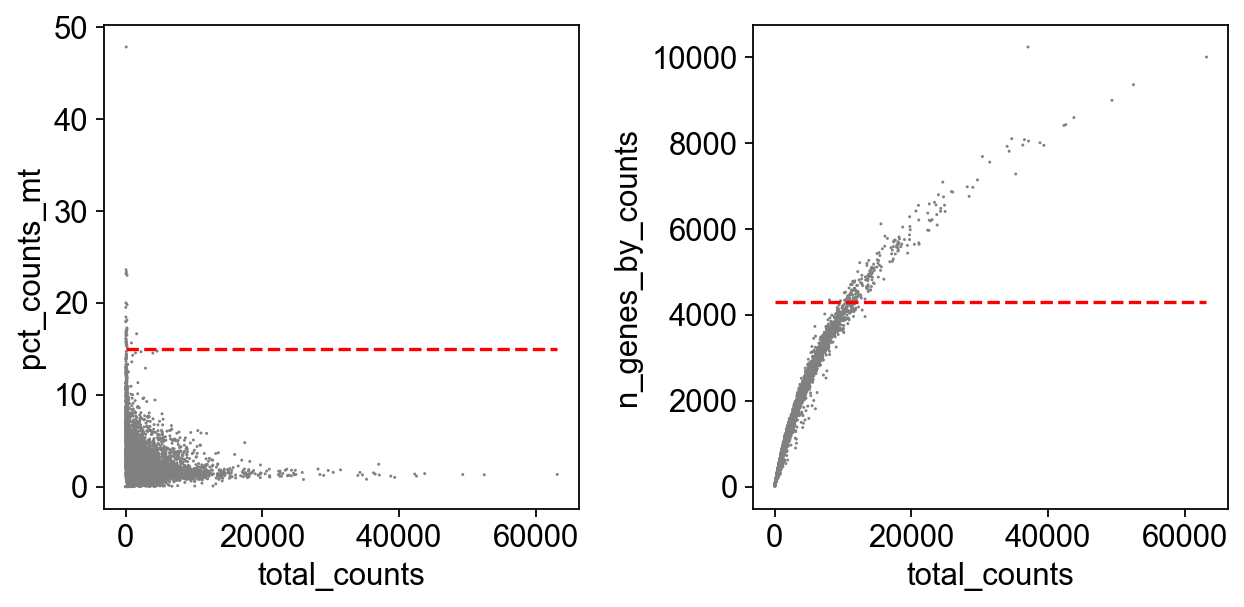

In [ ]:
import matplotlib.pyplot as plt
mito_filter = 15
n_counts_filter = 4300
fig, axs = plt.subplots(ncols = 2, figsize = (8,4))
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt',ax = axs[0], show=False)
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts',ax = axs[1], show = False)



#draw horizontal red lines indicating thresholds.
axs[0].hlines(y = mito_filter, xmin = 0, xmax = max(adata.obs['total_counts']), color = 'red', ls = 'dashed')
axs[1].hlines(y = n_counts_filter, xmin = 0, xmax = max(adata.obs['total_counts']), color = 'red', ls = 'dashed')
fig.tight_layout()
plt.show()


In [20]:
# Original QC plot
n0 = adata.shape[0]
print(f'Original cell number: {n0}')


Original cell number: 16934
